# Notebook 4 — Modelo Combinado: Conv1D + BiLSTM
**Descripción:** Modelo híbrido que combina redes convolucionales 1D (para extracción de n-gramas) con LSTM bidireccional (para dependencias secuenciales). Este enfoque captura tanto patrones locales como contexto global.

## 1. Setup

In [1]:
import os, json, pickle, warnings
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks, optimizers
from tensorflow.keras.utils import plot_model
from sklearn.metrics import (classification_report, confusion_matrix,
                              roc_auc_score, roc_curve, f1_score,
                              precision_score, recall_score, accuracy_score)
from sklearn.utils.class_weight import compute_class_weight

warnings.filterwarnings('ignore')
np.random.seed(42); tf.random.set_seed(42)

gpus = tf.config.list_physical_devices('GPU')
if gpus:
    tf.config.experimental.set_memory_growth(gpus[0], True)
    print(f"✅ GPU: {gpus[0].name}")
else:
    print("⚠️  CPU mode")

BASE_DIR = "results"
DIRS = {k: os.path.join(BASE_DIR, k) for k in ["data","figures","models/Combinado","metrics"]}
for d in DIRS.values(): os.makedirs(d, exist_ok=True)


⚠️  CPU mode


In [2]:
def load_dataset(prefix):
    base = os.path.join(DIRS["data"], prefix)
    with open(f"{base}/tokenizer.pkl","rb") as f:
        tok = pickle.load(f)
    with open(f"{base}/meta.json") as f:
        meta = json.load(f)
    data = {k: np.load(f"{base}/{k}.npy")
            for k in ["X_train","y_train","X_val","y_val","X_test","y_test"]}
    return tok, meta, data

tok_big, meta_big, data_big = load_dataset("big_ahr")
tok_bal, meta_bal, data_bal = load_dataset("balanced_ahr")

for name, meta, d in [("Big AHR", meta_big, data_big),("Balanced AHR", meta_bal, data_bal)]:
    print(f"{name:20s}: train={d['X_train'].shape[0]:>5,}  "
          f"val={d['X_val'].shape[0]:>4,}  test={d['X_test'].shape[0]:>4,}")


Big AHR             : train=12,714  val=1,589  test=1,590
Balanced AHR        : train=4,272  val= 534  test= 535


In [3]:
def get_class_weights(y_train):
    cw = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
    return {0: cw[0], 1: cw[1]}

def make_callbacks(model_name, patience=5):
    ckpt_path = os.path.join(DIRS["models/Combinado"], f"{model_name}_best.keras")
    return [
        callbacks.EarlyStopping(monitor='val_loss', patience=patience,
                                restore_best_weights=True, verbose=0),
        callbacks.ModelCheckpoint(ckpt_path, save_best_only=True,
                                  monitor='val_loss', verbose=0),
        callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                                    patience=3, min_lr=1e-6, verbose=0),
    ]

def train_model(model, config, data, dataset_name, use_class_weight=False):
    X_tr, y_tr   = data['X_train'], data['y_train']
    X_val, y_val = data['X_val'],   data['y_val']
    X_te, y_te   = data['X_test'],  data['y_test']

    model_id = f"{config['name']}_{dataset_name}"
    cw = get_class_weights(y_tr) if use_class_weight else None

    hist = model.fit(
        X_tr, y_tr,
        validation_data=(X_val, y_val),
        epochs=config['epochs'],
        batch_size=config['batch_size'],
        class_weight=cw,
        callbacks=make_callbacks(model_id, patience=config.get('patience',5)),
        verbose=1
    )
    return hist, model_id

def evaluate_model(model, data, model_id):
    X_te, y_te = data['X_test'], data['y_test']
    y_prob = model.predict(X_te, verbose=0).ravel()
    y_pred = (y_prob >= 0.5).astype(int)

    metrics = {
        "accuracy":  float(accuracy_score(y_te, y_pred)),
        "precision": float(precision_score(y_te, y_pred, zero_division=0)),
        "recall":    float(recall_score(y_te, y_pred, zero_division=0)),
        "f1":        float(f1_score(y_te, y_pred, zero_division=0)),
        "roc_auc":   float(roc_auc_score(y_te, y_prob)),
    }
    print(f"\n  [{model_id}]")
    for k, v in metrics.items():
        print(f"    {k:12s}: {v:.4f}")
    return metrics, y_pred, y_prob, y_te

def save_metrics(all_results, model_type):
    path = os.path.join(DIRS["metrics"], f"{model_type}_results.json")
    with open(path, "w") as f:
        json.dump(all_results, f, indent=2)
    print(f"✅ Métricas guardadas: {path}")

def plot_training_curves(histories, model_type):
    n = len(histories)
    fig, axes = plt.subplots(n, 2, figsize=(14, 4*n))
    if n == 1: axes = [axes]
    fig.suptitle(f"Curvas de Entrenamiento — {model_type}", fontsize=14, fontweight='bold')
    for i, (name, hist) in enumerate(histories):
        h = hist.history
        axes[i][0].plot(h['loss'],     label='Train Loss',  color='#e74c3c')
        axes[i][0].plot(h['val_loss'], label='Val Loss',    color='#3498db')
        axes[i][0].set_title(f"{name} — Loss"); axes[i][0].legend()
        axes[i][0].set_xlabel("Época"); axes[i][0].set_ylabel("Loss")

        axes[i][1].plot(h['accuracy'],     label='Train Acc', color='#27ae60')
        axes[i][1].plot(h['val_accuracy'], label='Val Acc',   color='#8e44ad')
        axes[i][1].set_title(f"{name} — Accuracy"); axes[i][1].legend()
        axes[i][1].set_xlabel("Época"); axes[i][1].set_ylabel("Accuracy")

    plt.tight_layout()
    path = os.path.join(DIRS["figures"], f"{model_type}_training_curves.png")
    plt.savefig(path, dpi=130, bbox_inches='tight')
    plt.show(); print(f"✅ {path}")

def plot_confusion_matrices(results_list, model_type):
    n = len(results_list)
    cols = min(n, 4)
    rows = (n + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(5*cols, 4*rows))
    axes = np.array(axes).flatten()
    fig.suptitle(f"Matrices de Confusión — {model_type}", fontsize=14, fontweight='bold')
    for i, (name, y_te, y_pred) in enumerate(results_list):
        cm = confusion_matrix(y_te, y_pred)
        sns.heatmap(cm, annot=True, fmt='d', ax=axes[i],
                    cmap='Blues', cbar=False,
                    xticklabels=['Neg','Pos'], yticklabels=['Neg','Pos'])
        axes[i].set_title(name, fontsize=10, fontweight='bold')
        axes[i].set_xlabel("Predicho"); axes[i].set_ylabel("Real")
    for j in range(i+1, len(axes)):
        axes[j].set_visible(False)
    plt.tight_layout()
    path = os.path.join(DIRS["figures"], f"{model_type}_confusion_matrices.png")
    plt.savefig(path, dpi=130, bbox_inches='tight')
    plt.show(); print(f"✅ {path}")

def plot_roc_curves(results_list, model_type):
    fig, ax = plt.subplots(figsize=(9, 7))
    colors = plt.cm.tab10(np.linspace(0, 1, len(results_list)))
    for (name, y_te, y_prob), clr in zip(results_list, colors):
        fpr, tpr, _ = roc_curve(y_te, y_prob)
        auc = roc_auc_score(y_te, y_prob)
        ax.plot(fpr, tpr, color=clr, lw=2, label=f"{name} (AUC={auc:.3f})")
    ax.plot([0,1],[0,1],'--', color='gray', lw=1)
    ax.set_xlabel("FPR"); ax.set_ylabel("TPR")
    ax.set_title(f"Curvas ROC — {model_type}", fontsize=14, fontweight='bold')
    ax.legend(loc='lower right', fontsize=8)
    plt.tight_layout()
    path = os.path.join(DIRS["figures"], f"{model_type}_roc_curves.png")
    plt.savefig(path, dpi=130, bbox_inches='tight'); plt.show()

def summarize_results(all_results, model_type):
    import pandas as pd
    rows = []
    for res in all_results:
        rows.append({
            "Modelo":    res["config"],
            "Dataset":   res["dataset"],
            "Accuracy":  res["metrics"]["accuracy"],
            "Precision": res["metrics"]["precision"],
            "Recall":    res["metrics"]["recall"],
            "F1-Score":  res["metrics"]["f1"],
            "ROC-AUC":   res["metrics"]["roc_auc"],
        })
    df = pd.DataFrame(rows)
    print("\n" + df.to_string(index=False))
    path = os.path.join(DIRS["metrics"], f"{model_type}_summary.csv")
    df.to_csv(path, index=False)
    print(f"\n✅ Tabla guardada: {path}")
    return df


## 2. Arquitecturas Conv1D + BiLSTM

Estrategia de diseño:
- **Conv1D**: actúa como detector de n-gramas (filtros locales)
- **MaxPooling / GlobalMaxPool**: reduce dimensionalidad
- **BiLSTM**: captura dependencias secuenciales largas
- **Configuraciones**: de 1 rama conv hasta multi-kernel con atención

In [5]:
CONV_LSTM_CONFIGS = [
    {
        "name":         "ConvLSTM_C1_Base",
        "vocab_size":    5000,
        "embed_dim":      64,
        "conv_filters":  [64],
        "kernel_sizes":  [3],
        "lstm_units":     64,
        "bidirectional":  True,
        "pool_type":     "max",
        "dropout":        0.25,
        "dense_units":   [32],
        "lr":             1e-3,
        "batch_size":     64,
        "epochs":          20,
        "patience":         5,
        "description": "Conv1D(64,k=3) → MaxPool → BiLSTM(64)"
    },
    {
        "name":         "ConvLSTM_C2_Medium",
        "vocab_size":   10000,
        "embed_dim":     128,
        "conv_filters":  [128, 64],
        "kernel_sizes":  [3, 5],
        "lstm_units":    128,
        "bidirectional":  True,
        "pool_type":     "max",
        "dropout":        0.35,
        "dense_units":   [64],
        "lr":             1e-3,
        "batch_size":    128,
        "epochs":          25,
        "patience":         6,
        "description": "2×Conv1D (k=3,5) → Pool → BiLSTM(128)"
    }
]

class SelfAttention(layers.Layer):
    """Self-attention para secuencias de salida de LSTM."""
    def __init__(self, **kwargs):
        super().__init__(**kwargs)
        self.W = layers.Dense(1, activation='tanh')

    def call(self, x):
        scores  = self.W(x)
        weights = tf.nn.softmax(scores, axis=1)
        return tf.reduce_sum(weights * x, axis=1)

def build_conv_lstm(config, vocab_size, max_len=150):
    inp  = layers.Input(shape=(max_len,))
    emb  = layers.Embedding(vocab_size,            # siempre el real del tokenizador
                             config['embed_dim'],    # embed_dim varía por config
                             mask_zero=False)(inp)
    emb  = layers.SpatialDropout1D(0.2)(emb)

    pool_type = config.get('pool_type', 'max')

    if pool_type == 'parallel':
        # ── Rama paralela por kernel ────────────────────────
        branches = []
        for filt, kern in zip(config['conv_filters'], config['kernel_sizes']):
            c = layers.Conv1D(filt, kern, activation='relu', padding='same')(emb)
            c = layers.GlobalMaxPooling1D()(c)
            branches.append(c)
        x = layers.Concatenate()(branches) if len(branches) > 1 else branches[0]
        # Proyectar a forma secuencial para LSTM
        x = layers.RepeatVector(max_len // 4)(x)

    else:
        # ── Rama secuencial con conv apilados ───────────────
        x = emb
        for i, (filt, kern) in enumerate(zip(config['conv_filters'], config['kernel_sizes'])):
            x = layers.Conv1D(filt, kern, activation='relu', padding='same',
                              name=f"conv_{i+1}")(x)
            x = layers.BatchNormalization()(x)
        x = layers.MaxPooling1D(pool_size=2)(x)
        x = layers.Dropout(config['dropout'])(x)

    # ── Capa BiLSTM ────────────────────────────────────────
    return_seq = config.get('use_attention', False)
    lstm = layers.LSTM(config['lstm_units'],
                       dropout=config['dropout'] * 0.5,
                       recurrent_dropout=config['dropout'] * 0.3,
                       return_sequences=return_seq,
                       name="lstm")
    if config.get('bidirectional', True):
        x = layers.Bidirectional(lstm, name="bilstm")(x)
    else:
        x = lstm(x)

    if config.get('use_attention', False):
        x = SelfAttention(name="self_attention")(x)

    for i, units in enumerate(config.get('dense_units', [])):
        x = layers.Dense(units, activation='relu', name=f"dense_{i+1}")(x)
        x = layers.Dropout(config['dropout'] * 0.5)(x)

    out = layers.Dense(1, activation='sigmoid')(x)
    model = models.Model(inp, out, name=config['name'])
    model.compile(optimizer=optimizers.Adam(config['lr']),
                  loss='binary_crossentropy', metrics=['accuracy'])
    return model

m_ex = build_conv_lstm(CONV_LSTM_CONFIGS[1], meta_big['vocab_size'])
m_ex.summary()

Model: "ConvLSTM_C2_Medium"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 150)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding (Embedding)           │ (None, 150, 128)       │     2,560,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d               │ (None, 150, 128)       │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_1 (Conv1D)                 │ (None, 150, 128)       │        49,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 150, 128)       │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_2 (Conv1D)                 │ (None, 150, 64)        │        41,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 150, 64)        │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 75, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 75, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bilstm (Bidirectional)          │ (None, 256)            │       197,632 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,865,217 (10.93 MB)

 Trainable params: 2,864,833 (10.93 MB)

 Non-trainable params: 384 (1.50 KB)

## 3. Entrenamiento

In [6]:
all_results   = []
all_histories = []
conf_matrix_data = []
roc_data         = []

DATASET_PAIRS = [
    ("balanced", data_bal, meta_bal, False),
    ("big_ahr",  data_big, meta_big, True),
]

for ds_name, data, meta, use_cw in DATASET_PAIRS:
    vs = meta['vocab_size']
    print(f"\n{'='*60}\n  DATASET: {ds_name.upper()}\n{'='*60}")
    for cfg in CONV_LSTM_CONFIGS:
        tf.keras.backend.clear_session()
        print(f"\n▶ {cfg['name']} | {cfg['description']}")
        model = build_conv_lstm(cfg, vs)
        hist, model_id = train_model(model, cfg, data, ds_name, use_class_weight=use_cw)
        mets, y_pred, y_prob, y_te = evaluate_model(model, data, model_id)
        all_results.append({
            "config": cfg['name'], "dataset": ds_name,
            "description": cfg['description'],
            "params": model.count_params(), "metrics": mets,
            "history": {k: [float(v) for v in vals]
                        for k, vals in hist.history.items()}
        })
        all_histories.append((model_id, hist))
        conf_matrix_data.append((model_id, y_te, y_pred))
        roc_data.append((model_id, y_te, y_prob))
        model.save(os.path.join(DIRS["models/Combinado"], f"{model_id}.keras"))
        print(f"  ✅ Params: {model.count_params():,}")

print("\n✅ Entrenamiento Conv1D+BiLSTM completado")


  DATASET: BALANCED

▶ ConvLSTM_C1_Base | Conv1D(64,k=3) → MaxPool → BiLSTM(64)
Epoch 1/20
67/67 ━━━━━━━━━━━━━━━━━━━━ 5s 30ms/step - accuracy: 0.8453 - loss: 0.3256 - val_accuracy: 0.9775 - val_loss: 0.4374 - learning_rate: 0.0010
Epoch 2/20
67/67 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - accuracy: 0.9904 - loss: 0.0336 - val_accuracy: 0.9757 - val_loss: 0.2586 - learning_rate: 0.0010
Epoch 3/20
67/67 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step - accuracy: 0.9979 - loss: 0.0093 - val_accuracy: 0.9700 - val_loss: 0.1300 - learning_rate: 0.0010
Epoch 4/20
67/67 ━━━━━━━━━━━━━━━━━━━━ 2s 27ms/step - accuracy: 0.9991 - loss: 0.0060 - val_accuracy: 0.9813 - val_loss: 0.0671 - learning_rate: 0.0010
Epoch 5/20
67/67 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step - accuracy: 0.9979 - loss: 0.0067 - val_accuracy: 0.9925 - val_loss: 0.0412 - learning_rate: 0.0010
Epoch 6/20
67/67 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - accuracy: 0.9986 - loss: 0.0042 - val_accuracy: 0.9925 - val_loss: 0.0315 - learning_rate: 0.0010
Epoch 7/20
67

## 4. Visualizaciones y Guardado

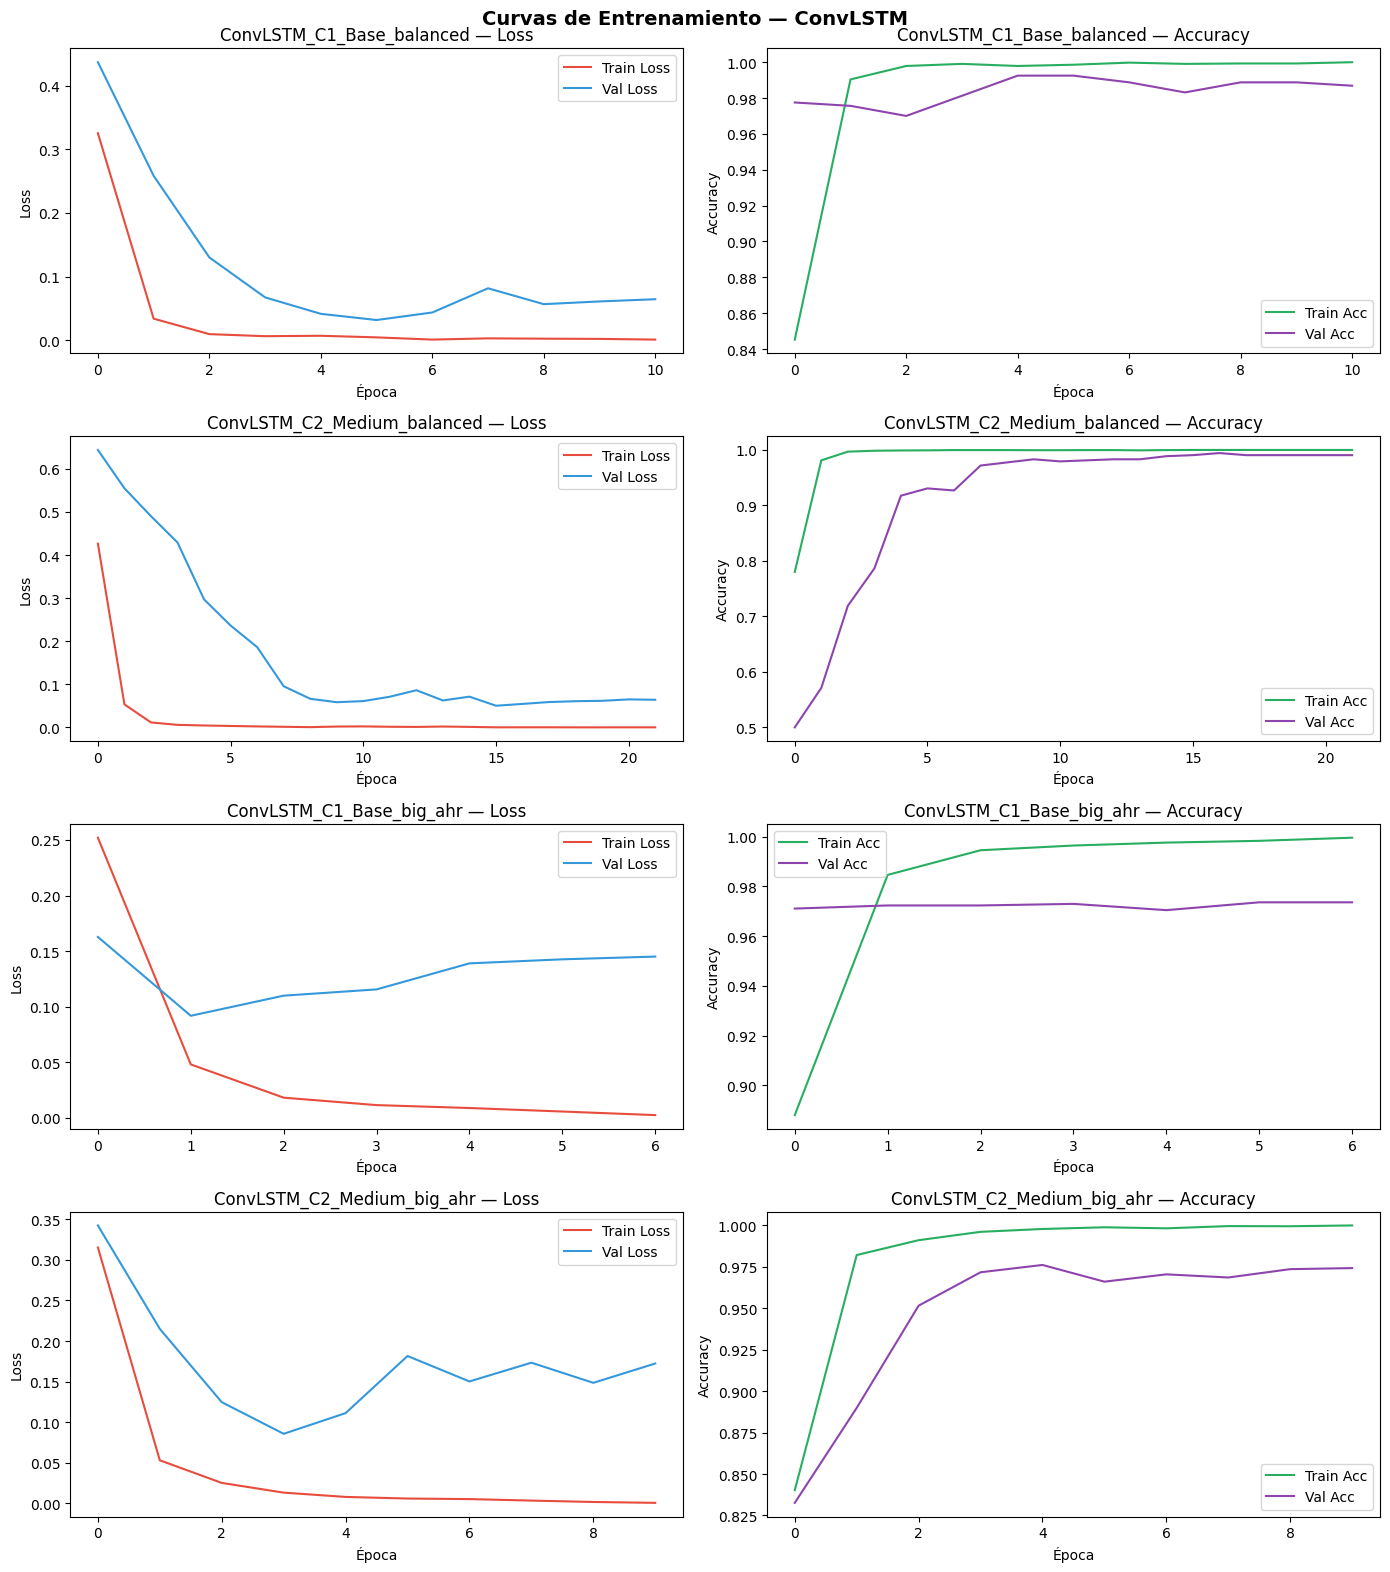

✅ results/figures/ConvLSTM_training_curves.png


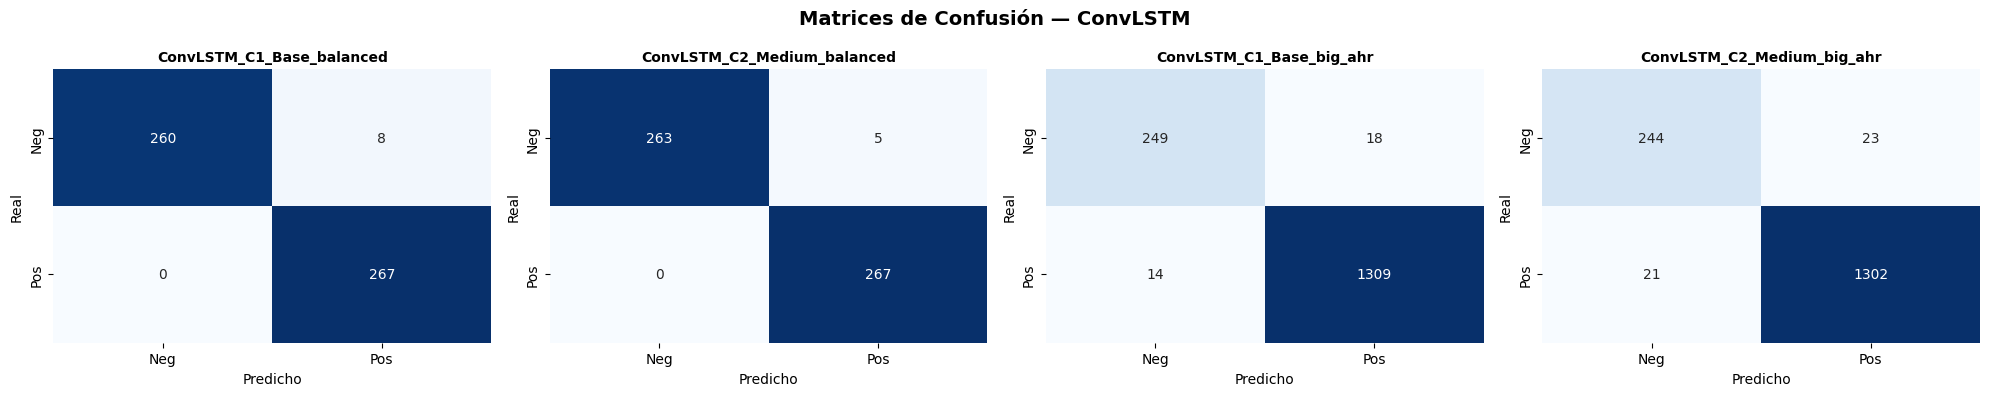

✅ results/figures/ConvLSTM_confusion_matrices.png


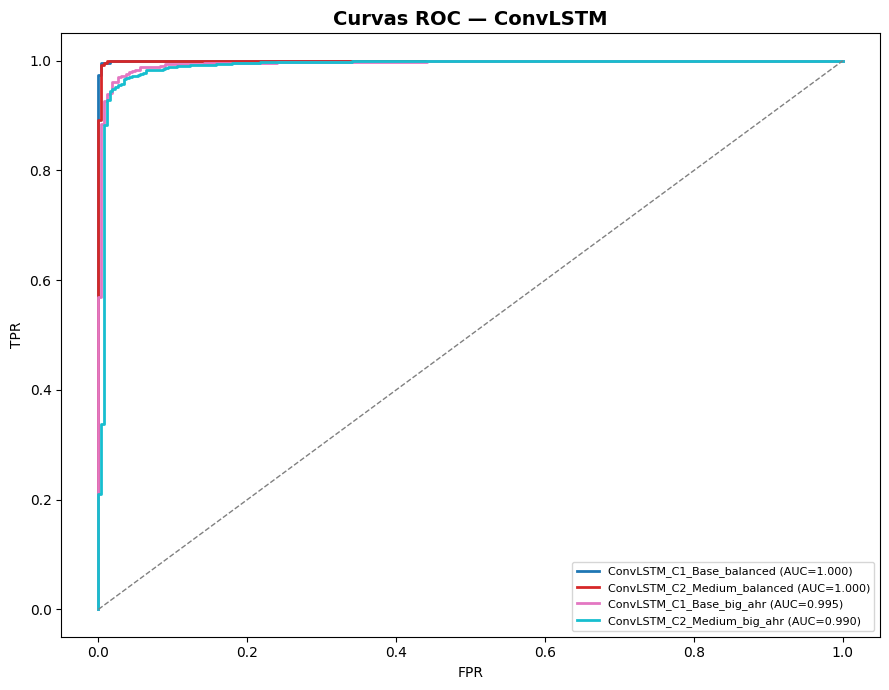

✅ Métricas guardadas: results/metrics/ConvLSTM_results.json

            Modelo  Dataset  Accuracy  Precision   Recall  F1-Score  ROC-AUC
  ConvLSTM_C1_Base balanced  0.985047   0.970909 1.000000  0.985240 0.999860
ConvLSTM_C2_Medium balanced  0.990654   0.981618 1.000000  0.990724 0.999553
  ConvLSTM_C1_Base  big_ahr  0.979874   0.986436 0.989418  0.987925 0.994672
ConvLSTM_C2_Medium  big_ahr  0.972327   0.982642 0.984127  0.983384 0.990471

✅ Tabla guardada: results/metrics/ConvLSTM_summary.csv


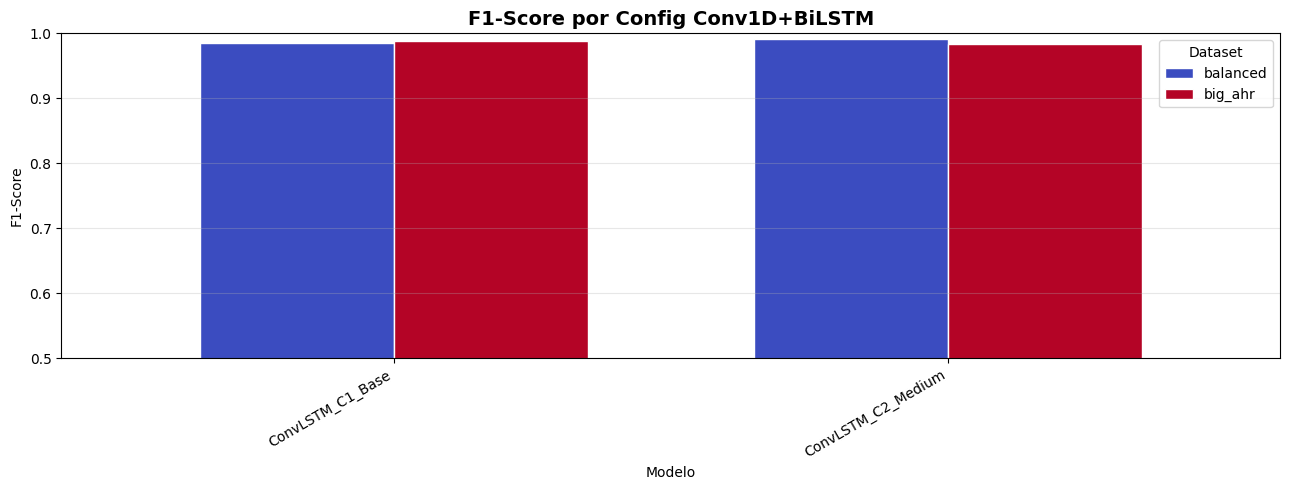

In [7]:
plot_training_curves(all_histories, "ConvLSTM")
plot_confusion_matrices(conf_matrix_data, "ConvLSTM")
plot_roc_curves(roc_data, "ConvLSTM")
save_metrics(all_results, "ConvLSTM")
df_summary = summarize_results(all_results, "ConvLSTM")

import pandas as pd
fig, ax = plt.subplots(figsize=(13, 5))
pivot = df_summary.pivot(index="Modelo", columns="Dataset", values="F1-Score")
pivot.plot(kind='bar', ax=ax, colormap='coolwarm', edgecolor='white', width=0.7)
ax.set_title("F1-Score por Config Conv1D+BiLSTM", fontsize=14, fontweight='bold')
ax.set_ylabel("F1-Score"); ax.set_ylim(0.5, 1.0)
ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right')
ax.legend(title="Dataset"); ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(DIRS["figures"], "ConvLSTM_f1_comparison.png"), dpi=130)
plt.show()